In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from scipy.integrate import quad
from scipy.stats import norm
import pandas as pd

CI is 29.2510
CI is 29.0764
CI is 26.7731
CI is 24.3124


C:\Users\wenlou\AppData\Local\Temp\ipykernel_6096\1084292358.py:65: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


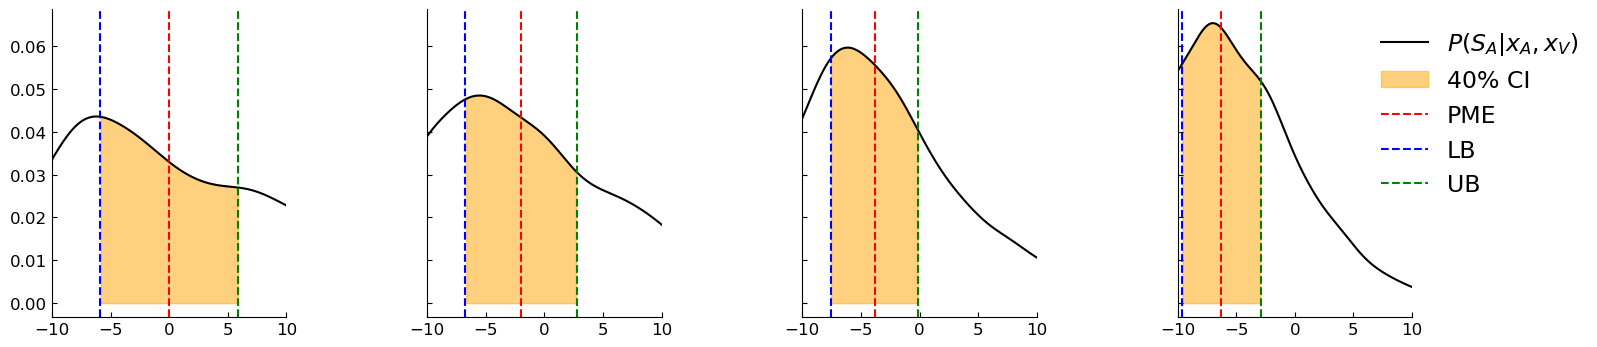

In [2]:
# Generate data for two normal distributions

sigV=5
sigA = 8
def get_x_y_vals(data):
    kde = gaussian_kde(data)
    x_vals = np.linspace(min(data) - 1, max(data) + 1, 1000)
    y_vals = kde(x_vals)
    MAP = x_vals[np.argmax(y_vals)]
    PME = data.mean()
    return x_vals, y_vals, MAP, PME, kde

def get_data(locV, locA, sigV, sigA):
    dataV = np.random.normal(loc=locV, scale=sigV, size=1000)
    dataA = np.random.normal(loc=locA, scale=sigA, size=1000)
    # Combine the data
    data = np.concatenate([dataV, dataA])
    x_vals, y_vals_mix, MAP, PME, kde = get_x_y_vals(data)
    y1 = norm.pdf(x_vals, locV, sigV)
    y2 = norm.pdf(x_vals, locA, sigA)
    return x_vals, y_vals_mix, PME, kde, y1, y2

# Calculate the bounds for central 80%
def find_interval(kde, x_center, x_vals, target_mass=0.4, step=0.01):
    left = x_center
    right = x_center
    total_range = x_vals[-1] - x_vals[0]
    max_expansion = total_range / 2

    while (right - left) < total_range:
        left = max(x_vals[0], left - step)
        right = min(x_vals[-1], right + step)
        area, _ = quad(kde, left, right)
        if area >= target_mass:
            return left, right, max_expansion
    return x_vals[0], x_vals[-1], max_expansion

# Plot the density
def plotDistribution(NAME, ax, locV, locA, leg=False):
    x_vals, y_vals, PME, kde, y1, y2 = get_data(locV, locA, sigV, sigA)
    lower_bound, upper_bound, CI = find_interval(kde, PME, x_vals)
    ax.plot(x_vals, y_vals, color='k', label = r'$P(S_A|x_A, x_V)$')
    ax.fill_between(x_vals, 0, y_vals, where=(x_vals >= lower_bound) & (x_vals <= upper_bound),
                     color='orange', alpha=0.5, label='40% CI')
    ax.axvline(PME, color='red', linestyle='--', label=NAME)
    ax.axvline(lower_bound, color='blue', linestyle='--', label='LB')
    ax.axvline(upper_bound, color='green', linestyle='--', label='UB')
    if leg:
        ax.legend(frameon=False, fontsize=fontsize+5, loc='upper right', bbox_to_anchor=(1.8, 1))
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(axis='both', which='major', direction='in', left=True, bottom=True, labelsize=fontsize)
    ax.set_xlim([-10, 10])
    print(f'CI is {CI:.4f}') 

fontsize =12
locV = -7
locA = 7
fig, axs = plt.subplots(nrows=1, ncols =4, figsize=(16, 4), gridspec_kw={'wspace':0.6}, sharey=True, )
plotDistribution('PME', axs[0], locV=-7, locA=7)
plotDistribution('PME', axs[1], locV=-7, locA=3)
plotDistribution('PME', axs[2], locV=-7, locA=-1)
plotDistribution('PME', axs[3], locV=-7, locA=-5, leg=True)
#plotDistribution(MAP, 'MAP', axs[1], y_vals_mix, kde)
plt.tight_layout()
plt.subplots_adjust(left=0.05)
plt.savefig('C:/Users/wenlou/Documents/01.Projects/2.Confidence/1.Writing/interval-based-CI.png', dpi = 300)
plt.show()

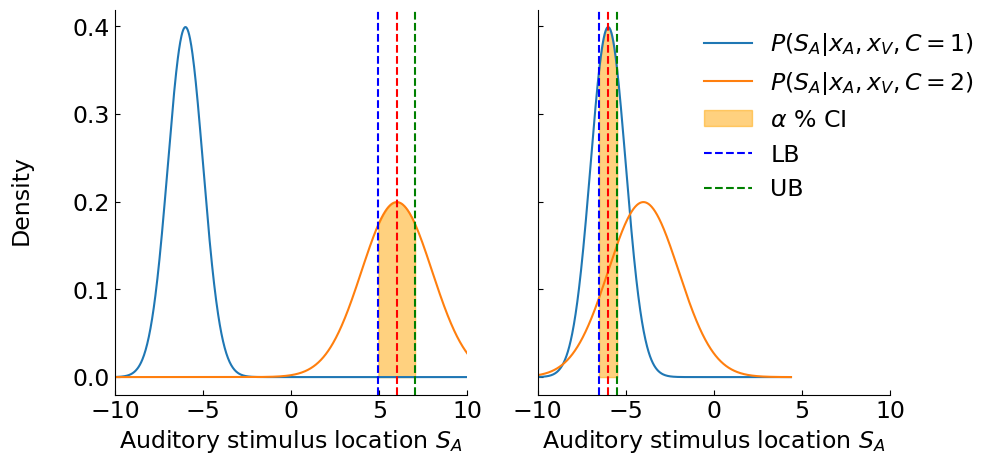

In [18]:
# Generate data for two normal distributions
LOC1 = -6
LOC2 = -4
sigV=1
sigA = 2
def get_data(LOC1, LOC2, switch = False):
    dataV = np.random.normal(loc=LOC1, scale=sigV, size=1000)
    dataA = np.random.normal(loc=LOC2, scale=sigA, size=1000)
    # Combine the data
    data = np.concatenate([dataV, dataA])

    var_c1 = 1/(1/(sigA**2) + 1/(sigV**2) + 1/100)
    var_c2 = 1/(1/(sigA**2) + 1/100)
    MU_C2 = (LOC2/(sigA**2))/var_c1
    MU_C1 = (LOC1/(sigV**2) + LOC2/(sigA**2))/var_c2 
    x_vals = np.linspace(min(data) - 1, max(data) + 1, 1000)
    y1 = norm.pdf(x_vals, LOC1, sigV)
    y2 = norm.pdf(x_vals, LOC2, sigA)
    ci_lb = norm.ppf((1 - ALP) / 2, LOC2, sigA)
    ci_ub = norm.ppf(1 - (1 - ALP) / 2, LOC2, sigA)
    if switch:
        ci_lb = norm.ppf((1 - ALP) / 2, LOC1, sigV)
        ci_ub = norm.ppf(1 - (1 - ALP) / 2, LOC1, sigV)
    return x_vals, y1, y2, ci_lb, ci_ub

def plot_ms(LOC1, LOC2, axs, switch=False, leg = False):
    x_vals, y1, y2, ci_lb, ci_ub = get_data(LOC1, LOC2, switch)
    axs.plot(x_vals, y1, label = r'$P(S_A|x_A, x_V, C=1)$')
    axs.plot(x_vals, y2, label = r'$P(S_A|x_A, x_V, C=2)$')
    if switch:
        axs.axvline(LOC1, color='red', linestyle='--')
        axs.fill_between(
        x_vals,
        0,
        y1,
        where=(x_vals >= ci_lb) & (x_vals <= ci_ub),
        color='orange',
        alpha=0.5,
        label=r'$\alpha$ % CI'
    )
    else:
        axs.axvline(LOC2, color='red', linestyle='--')
        axs.fill_between(
        x_vals,
        0,
        y2,
        where=(x_vals >= ci_lb) & (x_vals <= ci_ub),
        color='orange',
        alpha=0.5,
        label=r'$\alpha$ % CI'
    )
    axs.axvline(ci_lb, color='blue', linestyle='--', label='LB')
    axs.axvline(ci_ub, color='green', linestyle='--', label='UB')
    # axs.fill_between(
    #     x_vals,
    #     0,
    #     y1,
    #     where=(x_vals >= ci_lb) & (x_vals <= ci_ub),
    #     color='orange',
    #     alpha=0.5,
    #     label='\alpha % CI'
    # )
    if leg:
        axs.legend(frameon=False, fontsize=fontsize, loc='upper right', bbox_to_anchor=(1.3, 1))
    axs.spines['top'].set_visible(False)
    axs.spines['right'].set_visible(False)
    axs.tick_params(axis='both', which='major', direction='in', left=True, bottom=True, labelsize=fontsize)
    axs.set_xlim([-10, 10])


fontsize =12+5
ALP = 0.4
fig, axs = plt.subplots(nrows=1, ncols =2, figsize=(10, 5), gridspec_kw={'wspace':0.2}, sharey=True, )
plot_ms(-6, 6, axs[0], switch=False, leg = False)
#plot_ms(-6, 2, axs[1], switch=False, leg = False)
#plot_ms(-6, -2, axs[2],switch=True, leg = False)
plot_ms(-6, -4, axs[1],switch=True, leg = True)
axs[0].set_xlabel('Auditory stimulus location $S_A$', fontsize=fontsize)
axs[1].set_xlabel('Auditory stimulus location $S_A$', fontsize=fontsize)
fig.supylabel('Density', fontsize=fontsize)

plt.savefig('C:/Users/wenlou/Documents/01.Projects/2.Confidence/1.Writing/interval-based-CI2.png', dpi = 300)
plt.show()